<a href="https://colab.research.google.com/github/VedVar43789/TumorSense/blob/main/notebooks/modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modeling

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

In [9]:
data = load_breast_cancer(as_frame=True)
df = data.data
df['target'] = data.target

In [10]:
display(df.head())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [11]:
df.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target'],
      dtype='object')

In [16]:
# df.isnull().sum() # no missing values

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.feature_selection import RFE, RFECV
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve, f1_score, recall_score, precision_score

In [71]:
X = data.data.drop(columns=['target'], errors='ignore')
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Pipeline with StandardScaler, RFE, and SVC
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_selection', RFE(estimator=SVC(kernel='linear', class_weight='balanced'))),
    ('clf', SVC(class_weight='balanced'))
])

grid = {
    'clf__kernel': ['linear', 'rbf', 'poly'],
    'clf__C': [0.01, 0.1, 1, 10, 100],
    'clf__gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
    # 'feature_selection__estimator__C': [0.1, 1, 10]
}

model = GridSearchCV(
    pipeline,
    param_grid=grid,
    cv=5,
    scoring='f1'
)


In [72]:
model.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('feature_selection',
                                        RFE(estimator=SVC(class_weight='balanced',
                                                          kernel='linear'))),
                                       ('clf', SVC(class_weight='balanced'))]),
             param_grid={'clf__C': [0.01, 0.1, 1, 10, 100],
                         'clf__gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
                         'clf__kernel': ['linear', 'rbf', 'poly']},
             scoring='f1')

In [73]:
# Best params
model.best_params_

{'clf__C': 0.01, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}

In [74]:
# Best features

best_pipe = model.best_estimator_

rfe = best_pipe.named_steps['feature_selection']

selected_mask = rfe.support_

best_features = X.columns[selected_mask]

# Display the selected features
print(best_features)

Index(['mean perimeter', 'mean compactness', 'mean concave points',
       'mean symmetry', 'radius error', 'texture error', 'perimeter error',
       'area error', 'worst radius', 'worst texture', 'worst perimeter',
       'worst area', 'worst smoothness', 'worst concavity',
       'worst concave points'],
      dtype='object')


              precision    recall  f1-score   support

           0       0.98      0.95      0.96        42
           1       0.97      0.99      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



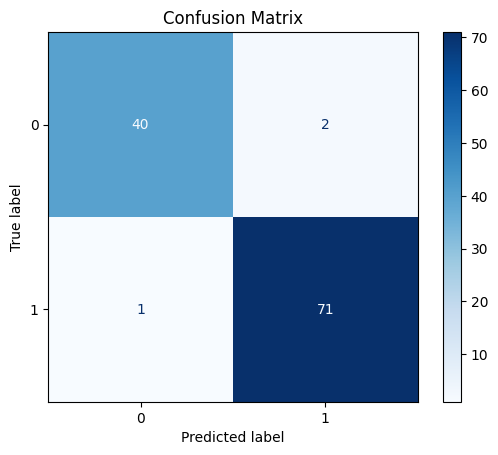

In [75]:
from sklearn.metrics import ConfusionMatrixDisplay

print(classification_report(y_test, model.predict(X_test)))

# Plot a visual confusion matrix
disp = ConfusionMatrixDisplay.from_predictions(y_test, model.predict(X_test), cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


Plotting decision boundary for top 2 features: 'worst radius' and 'worst texture'


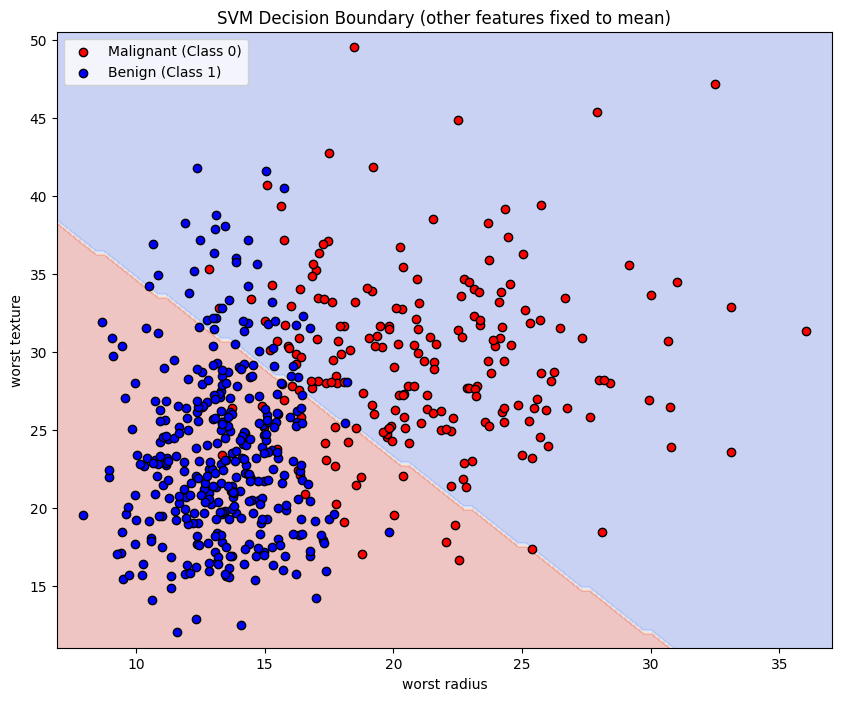

In [76]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Extract the best pipeline from GridSearchCV
best_pipe = model.best_estimator_

# Get the final SVC model and the RFE feature selector
final_svc = best_pipe.named_steps['clf']
rfe = best_pipe.named_steps['feature_selection']

# Find the names of the features that were selected by RFE
selected_mask = rfe.support_
selected_cols = X.columns[selected_mask]

# Find the top 2 most important features from the final linear SVC's coefficients
# (argsort sorts ascending, so we take the last two for the largest absolute coefficients)
top_2_sub_idx = np.argsort(np.abs(final_svc.coef_[0]))[-2:]
feat1, feat2 = selected_cols[top_2_sub_idx]

print(f"Plotting decision boundary for top 2 features: '{feat1}' and '{feat2}'")

# Create a meshgrid for the two features
x_min, x_max = X[feat1].min() - 1, X[feat1].max() + 1
y_min, y_max = X[feat2].min() - 1, X[feat2].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# Create a DataFrame to hold the grid points, filling all features with their mean values first
grid_df = pd.DataFrame(np.zeros((xx.size, X.shape[1])), columns=X.columns)
for col in X.columns:
    grid_df[col] = X_train[col].mean()

# Overwrite our two target features with the meshgrid values
grid_df[feat1] = xx.ravel()
grid_df[feat2] = yy.ravel()

# Predict using the full pipeline on the grid
Z = best_pipe.predict(grid_df)
Z = Z.reshape(xx.shape)

# Plotting
plt.figure(figsize=(10, 8))
# Plot the decision boundary
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

# Scatter plot the actual data
mask_pos = (y == 1) # Benign
mask_neg = (y == 0) # Malignant

plt.scatter(X.loc[mask_neg, feat1], X.loc[mask_neg, feat2], label="Malignant (Class 0)", color='red', edgecolor='k')
plt.scatter(X.loc[mask_pos, feat1], X.loc[mask_pos, feat2], label="Benign (Class 1)", color='blue', edgecolor='k')

plt.xlabel(feat1)
plt.ylabel(feat2)
plt.title("SVM Decision Boundary (other features fixed to mean)")
plt.legend()
plt.show()

In [77]:
# import joblib
# Save the model to a file
# joblib.dump(model, 'svc.joblib')

In [79]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

# Extract the best pipeline
best_pipe = model.best_estimator_
final_svc = best_pipe.named_steps['clf']
rfe = best_pipe.named_steps['feature_selection']
scaler = best_pipe.named_steps['scaler']

# 1. Identify top 3 features from the final SVC coefficients
selected_mask = rfe.support_
selected_cols = X.columns[selected_mask]
top_3_sub_idx = np.argsort(np.abs(final_svc.coef_[0]))[-3:]
feat1, feat2, feat3 = selected_cols[top_3_sub_idx]
print(f"Plotting 3D decision boundary for top 3 features: '{feat1}', '{feat2}', '{feat3}'")

# 2. Extract weights and standard scaler parameters
weights = final_svc.coef_[0]
intercept = final_svc.intercept_[0]

mean_all = scaler.mean_
scale_all = scaler.scale_
selected_indices = np.where(selected_mask)[0]

# Local indices for top 3 features in the 'weights' array
idx1, idx2, idx3 = top_3_sub_idx
w1, w2, w3 = weights[idx1], weights[idx2], weights[idx3]

# Original indices to get correct mean and scale
orig_idx1, orig_idx2, orig_idx3 = selected_indices[idx1], selected_indices[idx2], selected_indices[idx3]
m1, m2, m3 = mean_all[orig_idx1], mean_all[orig_idx2], mean_all[orig_idx3]
s1, s2, s3 = scale_all[orig_idx1], scale_all[orig_idx2], scale_all[orig_idx3]

# 3. Create a meshgrid for feat1 (X-axis) and feat2 (Y-axis)
x_min, x_max = X[feat1].min() - 1, X[feat1].max() + 1
y_min, y_max = X[feat2].min() - 1, X[feat2].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 30), np.linspace(y_min, y_max, 30))

# 4. Calculate zz (feat3) for the decision boundary
# The equation is sum(w_i * (x_i - mean_i) / scale_i) + b = 0
# For features held at mean, (x_i - mean_i) = 0, so they drop out.
zz = m3 + (s3 / w3) * (-intercept - w1*(xx - m1)/s1 - w2*(yy - m2)/s2)

# 5. Plotting with Plotly
fig = go.Figure()

# Plot the decision boundary plane
fig.add_trace(go.Surface(x=xx, y=yy, z=zz, opacity=0.3, colorscale='Greys', showscale=False, name='Decision Boundary'))

# Plot the actual data points
mask_pos = (y == 1) # Benign
mask_neg = (y == 0) # Malignant

fig.add_trace(go.Scatter3d(
    x=X.loc[mask_neg, feat1],
    y=X.loc[mask_neg, feat2],
    z=X.loc[mask_neg, feat3],
    mode='markers',
    marker=dict(size=4, color='red', line=dict(width=1, color='black')),
    name='Malignant (Class 0)'
))

fig.add_trace(go.Scatter3d(
    x=X.loc[mask_pos, feat1],
    y=X.loc[mask_pos, feat2],
    z=X.loc[mask_pos, feat3],
    mode='markers',
    marker=dict(size=4, color='blue', line=dict(width=1, color='black')),
    name='Benign (Class 1)'
))

fig.update_layout(
    title="3D SVM Decision Boundary (other features fixed to mean)",
    scene=dict(
        xaxis_title=feat1,
        yaxis_title=feat2,
        zaxis_title=feat3
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()


Plotting 3D decision boundary for top 3 features: 'worst concave points', 'worst radius', 'worst texture'
